Titik-titik Limas:
Alas: (0,0,0), (4,0,0), (4,4,0), (0,4,0)
Apex: (2,2,5)

Parameter Transformasi:
Skala: sx=1.5, sy=1.5, sz=0.8
Translasi: tx=2, ty=2, tz=0


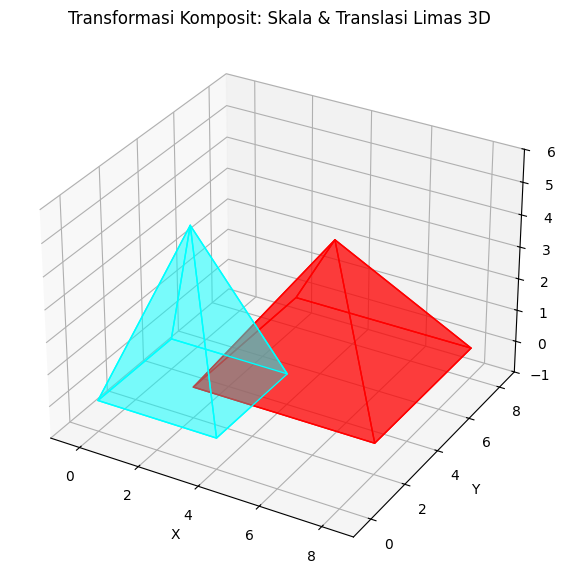

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1. Fungsi untuk menerapkan translasi (pergeseran)
def translate_pyramid(x, y, z, tx, ty, tz):
    translated_x = x + tx
    translated_y = y + ty
    translated_z = z + tz
    return translated_x, translated_y, translated_z

# 2. Fungsi untuk menerapkan penskalaan (perubahan ukuran)
def scale_pyramid(x, y, z, sx, sy, sz):
    scaled_x = x * sx
    scaled_y = y * sy
    scaled_z = z * sz
    return scaled_x, scaled_y, scaled_z

# --- MAIN PROGRAM ---

# Input Titik-Titik Limas (langsung dimasukkan)
# 4 titik alas persegi
base_x = [0, 4, 4, 0]
base_y = [0, 0, 4, 4]
base_z = [0, 0, 0, 0]

# Titik puncak (apex)
apex_x = 2
apex_y = 2
apex_z = 5

# Menggabungkan semua titik koordinat
x = np.array(base_x + [apex_x])
y = np.array(base_y + [apex_y])
z = np.array(base_z + [apex_z])

print("Titik-titik Limas:")
print(f"Alas: ({base_x[0]},{base_y[0]},{base_z[0]}), ({base_x[1]},{base_y[1]},{base_z[1]}), ({base_x[2]},{base_y[2]},{base_z[2]}), ({base_x[3]},{base_y[3]},{base_z[3]})")
print(f"Apex: ({apex_x},{apex_y},{apex_z})")

# Parameter Transformasi (langsung dimasukkan)
sx, sy, sz = 1.5, 1.5, 0.8  # Faktor skala
tx, ty, tz = 2, 2, 0        # Translasi

print(f"\nParameter Transformasi:")
print(f"Skala: sx={sx}, sy={sy}, sz={sz}")
print(f"Translasi: tx={tx}, ty={ty}, tz={tz}")

# Menerapkan Penskalaan terlebih dahulu
s_x, s_y, s_z = scale_pyramid(x, y, z, sx, sy, sz)

# Menerapkan Translasi pada hasil skala
final_x, final_y, final_z = translate_pyramid(s_x, s_y, s_z, tx, ty, tz)

# --- VISUALISASI ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Mendefinisikan urutan titik untuk membentuk permukaan poligon limas
def get_pyramid_faces(px, py, pz):
    faces = [
        [list(zip(px[:4], py[:4], pz[:4]))],                     # Alas
        [list(zip([px[0], px[1], px[4]], [py[0], py[1], py[4]], [pz[0], pz[1], pz[4]]))], # Sisi 1
        [list(zip([px[1], px[2], px[4]], [py[1], py[2], py[4]], [pz[1], pz[2], pz[4]]))], # Sisi 2
        [list(zip([px[2], px[3], px[4]], [py[2], py[3], py[4]], [pz[2], pz[3], pz[4]]))], # Sisi 3
        [list(zip([px[3], px[0], px[4]], [py[3], py[0], py[4]], [pz[3], pz[0], pz[4]]))]  # Sisi 4
    ]
    return faces

# Menggambar objek asli (Cyan)
for face in get_pyramid_faces(x, y, z):
    ax.add_collection3d(Poly3DCollection(face, color='cyan', alpha=0.3))

# Menggambar objek hasil transformasi (Red)
for face in get_pyramid_faces(final_x, final_y, final_z):
    ax.add_collection3d(Poly3DCollection(face, color='red', alpha=0.5))

# Label dan Pengaturan Plot
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Transformasi Komposit: Skala & Translasi Limas 3D')

# Batas Sumbu otomatis
all_x = np.concatenate([x, final_x])
all_y = np.concatenate([y, final_y])
all_z = np.concatenate([z, final_z])
ax.set_xlim([min(all_x) - 1, max(all_x) + 1])
ax.set_ylim([min(all_y) - 1, max(all_y) + 1])
ax.set_zlim([min(all_z) - 1, max(all_z) + 1])

plt.show()